In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import pandas as pd 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense






2026-06-02 18:31:45.023988: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780425105.065706     375 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780425105.078421     375 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780425105.137971     375 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780425105.138022     375 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780425105.138025     375 computation_placer.cc:177] computation placer alr

In [7]:
df=pd.read_csv( "/kaggle/input/datasets/robikscube/hourly-energy-consumption/PJME_hourly.csv")
#setting the datetime column as the index
df=df.set_index("Datetime") 
#casting the date column from object to datetime
df.index=pd.to_datetime(df.index)


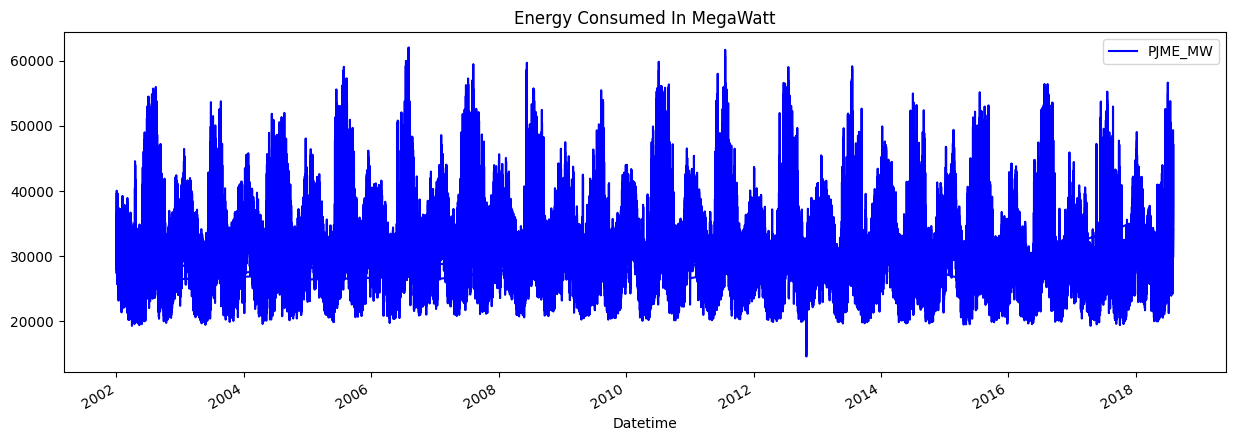

In [8]:
#Visualizing the data 

df.plot(style="-", figsize=(15, 5), color="b", title="Energy Consumed In MegaWatt")
plt.show()


In [9]:
df.head(5)

,PJME_MW
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0
2002-12-31 04:00:00,24393.0
2002-12-31 05:00:00,24860.0


In [23]:
data=df[["PJME_MW"]].values
data.shape

(145366, 1)

In [24]:
#Data Normalization
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)
data_scaled

array([[0.25184873],
       [0.22338565],
       [0.2113136 ],
       ...,
       [0.58691668],
       [0.53976614],
       [0.50698409]], shape=(145366, 1))

In [25]:
#Create sequences (time-series windowing)
def create_dataset(data, time_step=24):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step])
        y.append(data[i+time_step])
    return np.array(X), np.array(y)

time_step = 24
X, y = create_dataset(data_scaled, time_step)

X = X.reshape(X.shape[0], X.shape[1], 1)

In [26]:
#Splitting the data into train and testing split 
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [31]:
X_test.shape

(29069, 24, 1)

In [32]:
#Building the Model 
model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(time_step, 1)))
model.add(LSTM(32))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
model.summary()

2026-06-02 18:51:04.405315: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
#Training the model
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/10
3634/3634 ━━━━━━━━━━━━━━━━━━━━ 82s 22ms/step - loss: 0.0016 - val_loss: 4.2426e-04
Epoch 2/10
3634/3634 ━━━━━━━━━━━━━━━━━━━━ 81s 22ms/step - loss: 3.8137e-04 - val_loss: 3.5140e-04
Epoch 3/10
3634/3634 ━━━━━━━━━━━━━━━━━━━━ 80s 22ms/step - loss: 3.2600e-04 - val_loss: 3.0666e-04
Epoch 4/10
3634/3634 ━━━━━━━━━━━━━━━━━━━━ 80s 22ms/step - loss: 2.7017e-04 - val_loss: 3.0384e-04
Epoch 5/10
3634/3634 ━━━━━━━━━━━━━━━━━━━━ 79s 22ms/step - loss: 2.4725e-04 - val_loss: 2.4765e-04
Epoch 6/10
3634/3634 ━━━━━━━━━━━━━━━━━━━━ 80s 22ms/step - loss: 2.3136e-04 - val_loss: 2.3908e-04
Epoch 7/10
3634/3634 ━━━━━━━━━━━━━━━━━━━━ 80s 22ms/step - loss: 2.1755e-04 - val_loss: 2.4098e-04
Epoch 8/10
3634/3634 ━━━━━━━━━━━━━━━━━━━━ 80s 22ms/step - loss: 2.0521e-04 - val_loss: 2.2552e-04
Epoch 9/10
3634/3634 ━━━━━━━━━━━━━━━━━━━━ 79s 22ms/step - loss: 1.9288e-04 - val_loss: 2.8187e-04
Epoch 10/10
3634/3634 ━━━━━━━━━━━━━━━━━━━━ 79s 22ms/step - loss: 1.8201e-04 - val_loss: 2.0652e-04


In [34]:
#Predictions
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_pred = scaler.inverse_transform(train_pred)
test_pred = scaler.inverse_transform(test_pred)

y_train_inv = scaler.inverse_transform(y_train)
y_test_inv = scaler.inverse_transform(y_test)

3634/3634 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step
909/909 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step


In [37]:
#Evaluation metrics
mae = mean_absolute_error(y_test_inv, test_pred)
rmse = np.sqrt(mean_squared_error(y_test_inv, test_pred))
mape = np.mean(np.abs((y_test_inv - test_pred) / y_test_inv)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 404.240589470312
RMSE: 682.1154458449414
MAPE: 1.3152524467536868


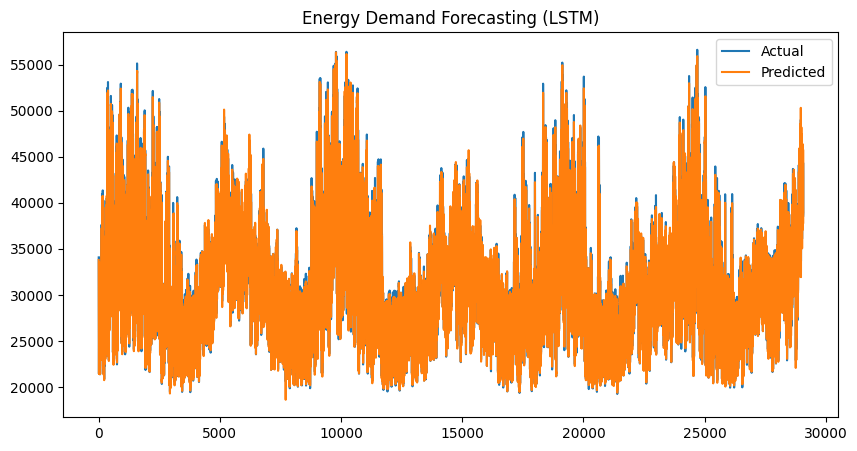

In [38]:
#Plot results
plt.figure(figsize=(10,5))
plt.plot(y_test_inv, label="Actual")
plt.plot(test_pred, label="Predicted")
plt.legend()
plt.title("Energy Demand Forecasting (LSTM)")
plt.show()

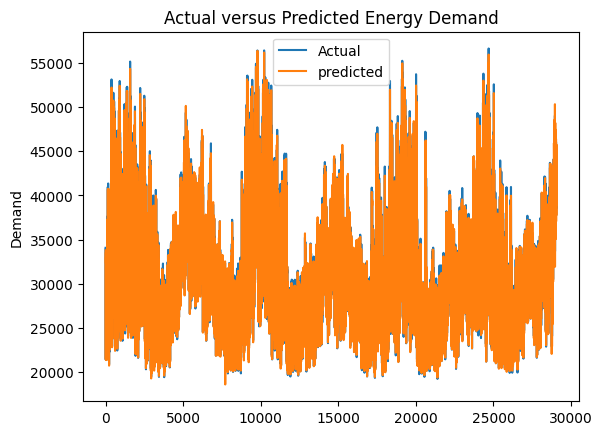

In [46]:
#Actual versus Predicted plot
plt.plot(y_test_inv, label="Actual")
plt.plot(test_pred, label="predicted")
plt.title("Actual versus Predicted Energy Demand")
plt.ylabel("Demand")
plt.legend()
plt.show()

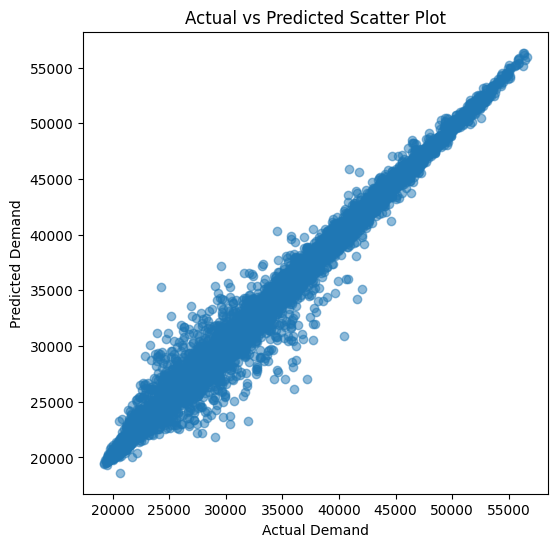

In [45]:
#Correlation plot 
plt.figure(figsize=(6,6))

plt.scatter(y_test_inv, test_pred, alpha=0.5)

plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')
plt.title('Actual vs Predicted Scatter Plot')

plt.show()

In [50]:
#Saving the model
model.save("LSTM_ENERFY_FORECSTING_MODEL.keras")

In [53]:
from tensorflow.keras.models import load_model

model_loaded = load_model("LSTM_ENERFY_FORECSTING_MODEL.keras")

In [55]:
model_loaded.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 88,037 (343.90 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 58,692 (229.27 KB)

In [1]:
import os


print(os.listdir())

['.virtual_documents']
